# Bitcoin Sentiment Analysis
This notebook performs real-time Bitcoin sentiment analysis using news data and price information.

## Setup and Dependencies

## Initialize API Clients

In [27]:
from src.common import NEWS_API_KEY, RELEVANT_SOURCES, newsapi, coingecko

In [28]:
from src.fetch_data import fetch_bitcoin_news, fetch_bitcoin_prices
from src.data_saver import save_data, load_data, format_sentiment_score#, get_sentiment_color 



from src.utils_analyzer import analyze_sentiment, aggregate_sentiment, prepare_time_series_data, run_forecast, compare_historical_sentiment

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

use_cached_data = True  # Set to False to fetch fresh data

# Date range
end_date = datetime.now().date()
start_date = end_date - timedelta(days=29)
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

In [32]:
# === 1. Fetch and Process News Articles ===
if use_cached_data:
    print("Loading cached news articles and sentiment data...")
    articles = load_data("articles_data.csv")
    aggregated_sentiment = load_data("aggregated_sentiment.csv")
else:
    print("Fetching Bitcoin-related news...")
    new_articles_fetch = fetch_bitcoin_news(start_date_str, end_date_str, refresh=True)
    new_articles = analyze_sentiment(new_articles_fetch)

    # Load old data and merge
    old_articles = load_data("articles_data.csv")
    if old_articles is not None:
        articles = pd.concat([old_articles, new_articles], ignore_index=True)
        # articles = articles.drop_duplicates(subset=['url'])
        
    else:
        articles = new_articles

    # Aggregate sentiment
    aggregated_sentiment = aggregate_sentiment(articles)

    # Save updated versions
    save_data(articles, "articles_data.csv")
    save_data(aggregated_sentiment, "aggregated_sentiment.csv")


Fetching Bitcoin-related news...
2025-05-18 03:53:11 - src.common - INFO - Using valid NewsAPI key
2025-05-18 03:53:28 - src.common - INFO - Loaded data from data/bitcoin_news.csv
2025-05-18 03:53:29 - src.common - ERROR - Error fetching news: Reindexing only valid with uniquely valued Index objects
2025-05-18 03:53:29 - src.utils_analyzer - WARNING - No articles to analyze.
2025-05-18 03:53:29 - src.common - INFO - Loaded data from data/articles_data.csv
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Aggregating sentiment data by date...
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Articles date range: 2025-04-15 00:00:00 to 2025-05-13 00:00:00
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Total articles by date: {Timestamp('2025-04-15 00:00:00'): 1, Timestamp('2025-04-16 00:00:00'): 1, Timestamp('2025-04-19 00:00:00'): 2, Timestamp('2025-04-20 00:00:00'): 1, Timestamp('2025-04-21 00:00:00'): 2, Timestamp('2025-04-22 00:00:00'): 2, Timestamp('2025-04-23 00:00:00'): 3, Time

In [33]:

# === 2. Fetch and Process Bitcoin Prices ===
if use_cached_data:
    print("Loading cached Bitcoin price data...")
    price_data = load_data("price_data.csv")
else:
    print("Fetching Bitcoin price data...")
    new_prices = fetch_bitcoin_prices(start_date_str, end_date_str, refresh=True)

    # Load old data and merge
    old_prices = load_data("price_data.csv")
    if old_prices is not None:
        price_data = pd.concat([old_prices, new_prices], ignore_index=True)
        price_data = price_data.drop_duplicates(subset=['date'])
    else:
        price_data = new_prices

    save_data(price_data, "price_data.csv")

Fetching Bitcoin price data...
2025-05-18 03:53:29 - src.common - INFO - Fetching Bitcoin price data from CoinGecko API...
2025-05-18 03:53:29 - src.common - INFO - Fetching Bitcoin price data from CoinGecko API...
2025-05-18 03:53:29 - src.common - INFO - Retrieved Bitcoin price data for 699 hours.
2025-05-18 03:53:29 - src.common - INFO - Loaded data from data/price_data.csv
2025-05-18 03:53:29 - src.common - INFO - Saved data to data/price_data.csv


/app/src/fetch_data.py:197: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['hour'] = df['timestamp'].dt.floor('H')


In [34]:
# === 3. Prepare Time Series ===
print("Merging sentiment and price data...")
merged_data = prepare_time_series_data(aggregated_sentiment, price_data)
# merged_data['price_diff'] = merged_data['close_price'].diff().dropna()
if merged_data is not None:
    merged_data = merged_data.drop_duplicates()
# merged_data

Merging sentiment and price data...
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Preparing time series data...
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Sentiment date range: 2025-04-15 00:00:00 to 2025-05-13 00:00:00
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Price date range: 2025-04-15 00:00:00 to 2025-05-18 03:00:00
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Time series data prepared with 579 days.


In [35]:






# === 4. Run Forecast ===
print("Running forecast...")
forecast_results, future_forecast = run_forecast(merged_data)

# === 5. Visualization with Matplotlib / Seaborn ===
def plot_sentiment_trends(sentiment_df):
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=sentiment_df, x='date', y='avg_polarity', ax=ax)
    ax.set_title("Average Sentiment Polarity Over Time")
    ax.set_ylabel("Polarity")
    ax.set_xlabel("Date")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_price_trends(price_df):
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.lineplot(data=price_df, x='date', y='close_price', ax=ax)
    ax.set_title("Bitcoin Close Price Over Time")
    ax.set_ylabel("Price (USD)")
    ax.set_xlabel("Date")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_price_vs_sentiment(merged_df):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=merged_df, x='avg_polarity', y='price', ax=ax)
    sns.regplot(data=merged_df, x='avg_polarity', y='price', scatter=False, ax=ax, color='red')
    ax.set_title("Bitcoin Price vs Sentiment Polarity")
    ax.set_ylabel("Price (USD)")
    ax.set_xlabel("Sentiment Polarity")
    plt.tight_layout()
    plt.show()

def plot_forecast(forecast_df):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(forecast_df['date'], forecast_df['actual_price'], label='Actual', color='blue')
    ax.plot(forecast_df['date'], forecast_df['predicted_price'], label='Forecast', linestyle='--', color='orange')
    ax.fill_between(
        forecast_df['date'],
        forecast_df['lower_ci'],
        forecast_df['upper_ci'],
        color='orange',
        alpha=0.2,
        label='95% CI'
    )
    ax.set_title("Forecast vs Actual Bitcoin Price")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_future_forecast(future_forecast):
    plt.figure(figsize=(10, 5))
    plt.plot(future_forecast['date'], future_forecast['predicted_price'], marker='o', label='Predicted Price')
    plt.title('7-Day Bitcoin Price Forecast')
    plt.xlabel('Date')
    plt.ylabel('Predicted Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Run visualizations




Running forecast...
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Running time series forecasting (hourly)...
2025-05-18 03:53:29 - src.utils_analyzer - INFO - Using ARIMA parameters: (5, 2, 2)
2025-05-18 03:53:33 - src.utils_analyzer - INFO - Model MAPE: 23.29%
2025-05-18 03:53:33 - src.utils_analyzer - INFO - Model RMSE: 28447.56
2025-05-18 03:53:33 - src.utils_analyzer - INFO - Forecast completed successfully (hourly).


/usr/local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [37]:
future_forecast

,date,predicted_price
0,2025-05-13 01:00:00,99084.217838
1,2025-05-13 02:00:00,99603.076052
2,2025-05-13 03:00:00,100074.219733
3,2025-05-13 04:00:00,100537.452244
4,2025-05-13 05:00:00,101012.644217
...,...,...
163,2025-05-19 20:00:00,170223.903161
164,2025-05-19 21:00:00,170656.868328
165,2025-05-19 22:00:00,171089.833495
166,2025-05-19 23:00:00,171522.798660


In [38]:
forecast_results

,date,actual_price,predicted_price,avg_polarity,upper_ci,lower_ci,mape,rmse
0,2025-05-08 04:00:00,99037.210880,99214.099472,0.110357,154971.311743,43456.887201,23.289695,28447.557281
1,2025-05-08 05:00:00,99095.087789,99776.201298,0.110357,155533.413569,44018.989027,23.289695,28447.557281
2,2025-05-08 06:00:00,98684.108985,100290.588592,0.110357,156047.800863,44533.376321,23.289695,28447.557281
3,2025-05-08 07:00:00,98990.049788,100797.064715,0.110357,156554.276986,45039.852444,23.289695,28447.557281
4,2025-05-08 08:00:00,99109.172493,101315.500301,0.110357,157072.712572,45558.288030,23.289695,28447.557281
...,...,...,...,...,...,...,...,...
111,2025-05-12 20:00:00,101821.248197,152639.475789,0.083333,208396.688060,96882.263518,23.289695,28447.557281
112,2025-05-12 21:00:00,102722.178294,153115.685576,0.083333,208872.897847,97358.473305,23.289695,28447.557281
113,2025-05-12 22:00:00,102535.074390,153591.895269,0.083333,209349.107540,97834.682998,23.289695,28447.557281
114,2025-05-12 23:00:00,102853.644071,154068.104876,0.083333,209825.317147,98310.892605,23.289695,28447.557281


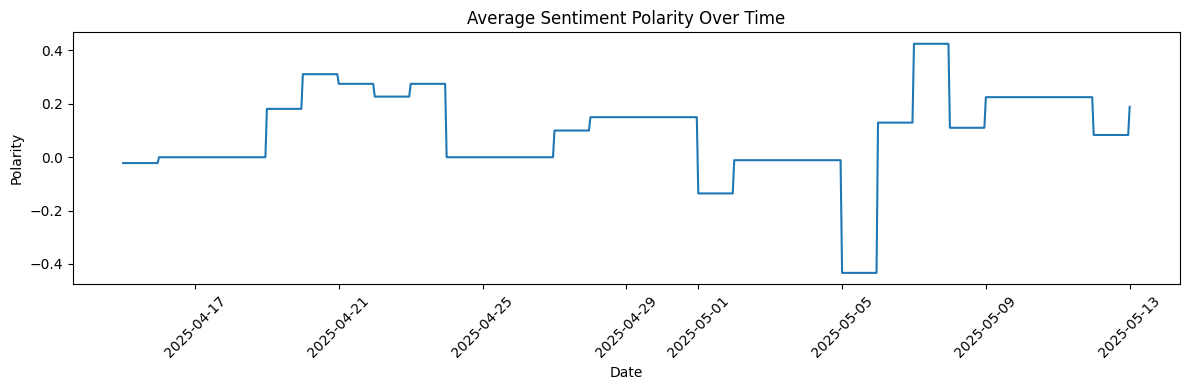

In [39]:
plot_sentiment_trends(aggregated_sentiment)


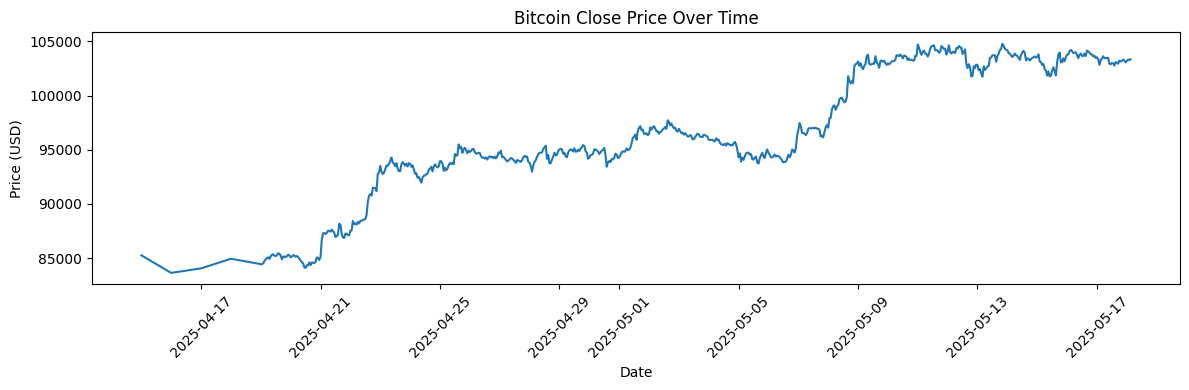

In [40]:
plot_price_trends(price_data)


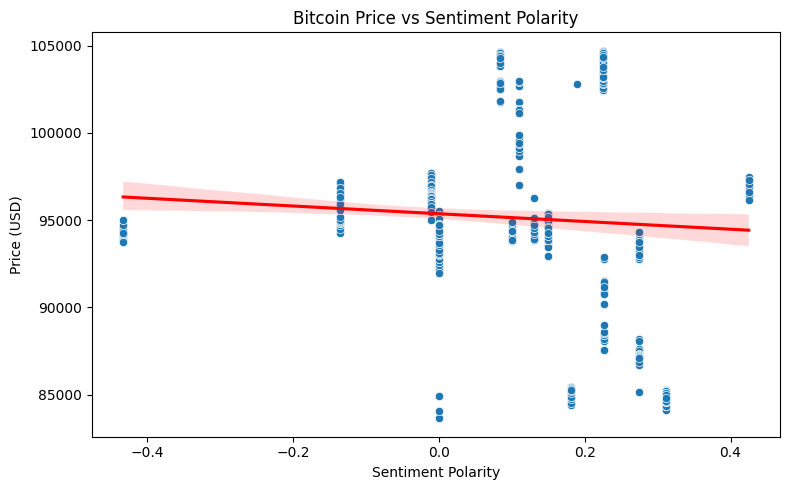

In [41]:
plot_price_vs_sentiment(merged_data)


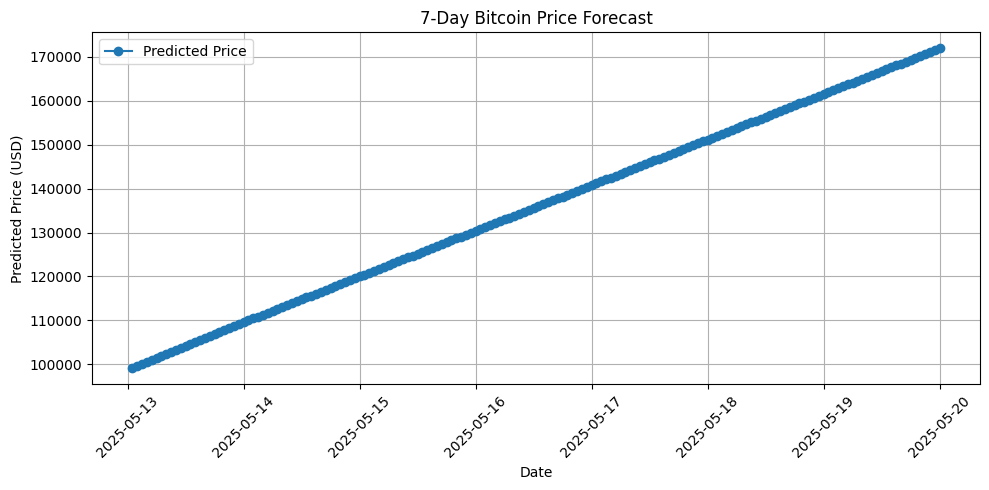

In [42]:
plot_future_forecast(future_forecast)  # if you're returning both results


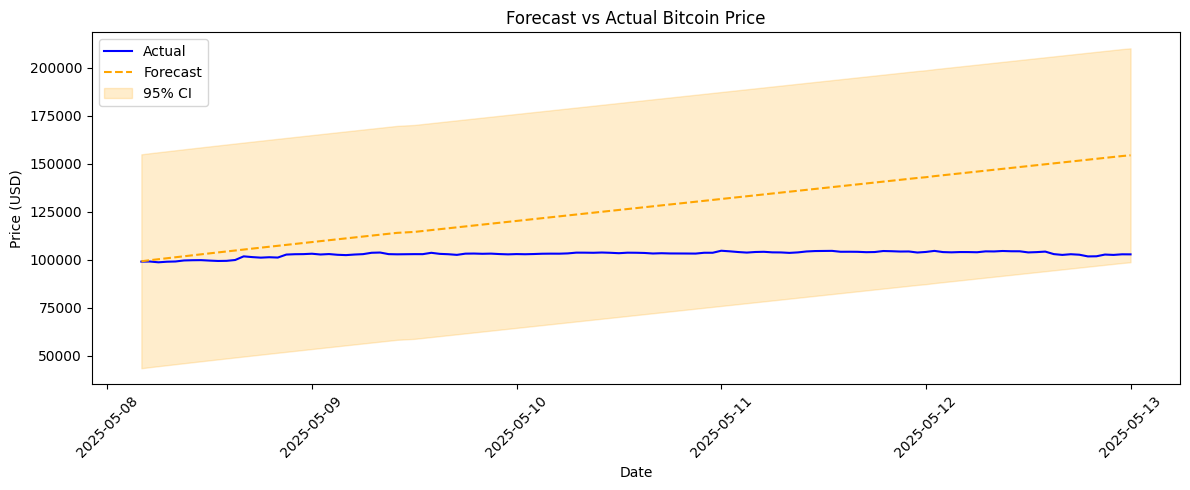

In [43]:
if forecast_results is not None:
    plot_forecast(forecast_results)



In [44]:
# === 6. Historical Comparison (Example) ===
comparison = compare_historical_sentiment(
    base_date=start_date_str,
    comparison_date=end_date_str,
    sentiment_df=aggregated_sentiment,
    price_df=price_data
)
print("\nHistorical Comparison:")
print(comparison)

2025-05-18 03:54:24 - src.utils_analyzer - WARNING - Missing data for comparison between 2025-04-19 and 2025-05-18

Historical Comparison:
None


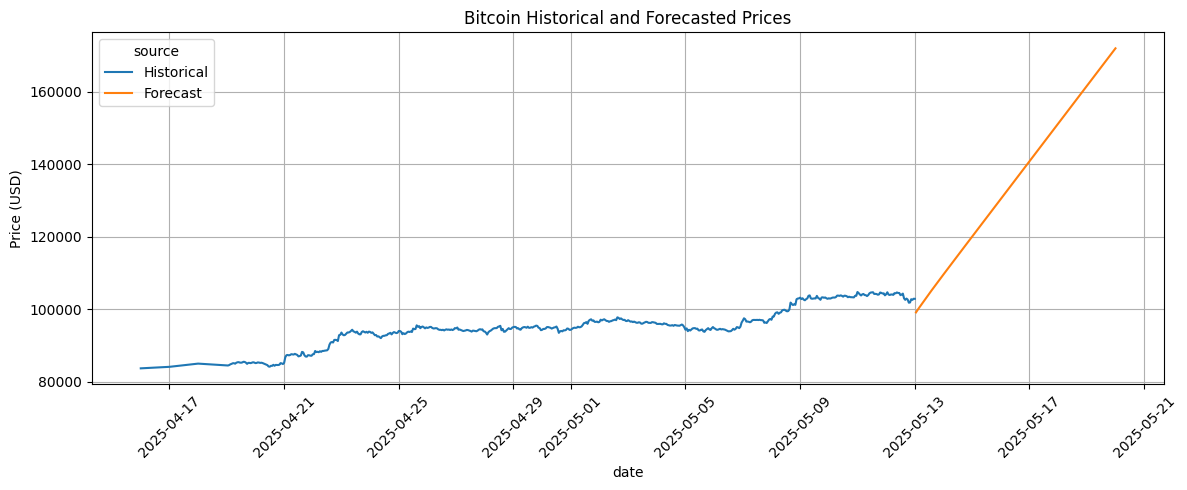

In [45]:
future = future_forecast.copy()
future['price'] = future['predicted_price']
future['source'] = 'Forecast'

historical = merged_data[['date', 'close_price']].copy()
historical['price'] = historical['close_price']
historical['source'] = 'Historical'

trend_df = pd.concat([historical[['date', 'price', 'source']], future[['date', 'price', 'source']]])

# plot it
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_df, x='date', y='price', hue='source')
plt.title('Bitcoin Historical and Forecasted Prices')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
trend_df

,date,price,source
1,2025-04-16 00:00:00,83641.904189,Historical
2,2025-04-17 00:00:00,84058.847670,Historical
3,2025-04-18 00:00:00,84946.916730,Historical
4,2025-04-19 00:00:00,84447.777181,Historical
5,2025-04-19 01:00:00,84430.134169,Historical
...,...,...,...
163,2025-05-19 20:00:00,170223.903161,Forecast
164,2025-05-19 21:00:00,170656.868328,Forecast
165,2025-05-19 22:00:00,171089.833495,Forecast
166,2025-05-19 23:00:00,171522.798660,Forecast


In [47]:
from src.models import run_auto_arima_forecast, run_lstm_forecast

# auto_arima_forecast = run_auto_arima_forecast(merged_data, forecast_hours=(24*7))
# lstm_forecast = run_lstm_forecast(merged_data, forecast_hours=(24*7), sequence_length=(24*7))


auto_arima_future, auto_arima_forecast = run_auto_arima_forecast(merged_data, forecast_hours=24*3)
lstm_future, lstm_forecast = run_lstm_forecast(merged_data, forecast_hours=24*3, sequence_length=24)

/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

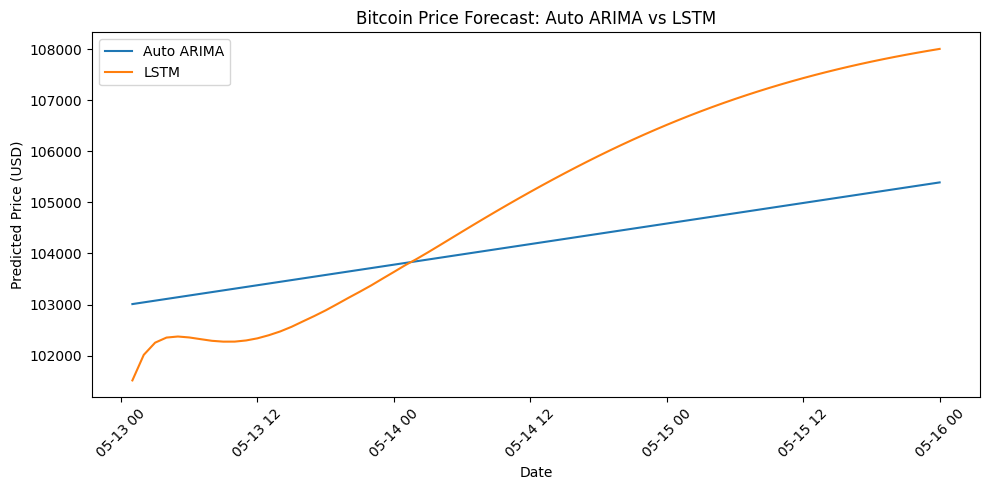

In [48]:
plt.figure(figsize=(10,5))
plt.plot(auto_arima_forecast['date'], auto_arima_forecast['predicted_price'], label='Auto ARIMA')
plt.plot(lstm_forecast['date'], lstm_forecast['predicted_price'], label='LSTM')
plt.legend()
plt.title('Bitcoin Price Forecast: Auto ARIMA vs LSTM')
plt.xlabel('Date')
plt.ylabel('Predicted Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

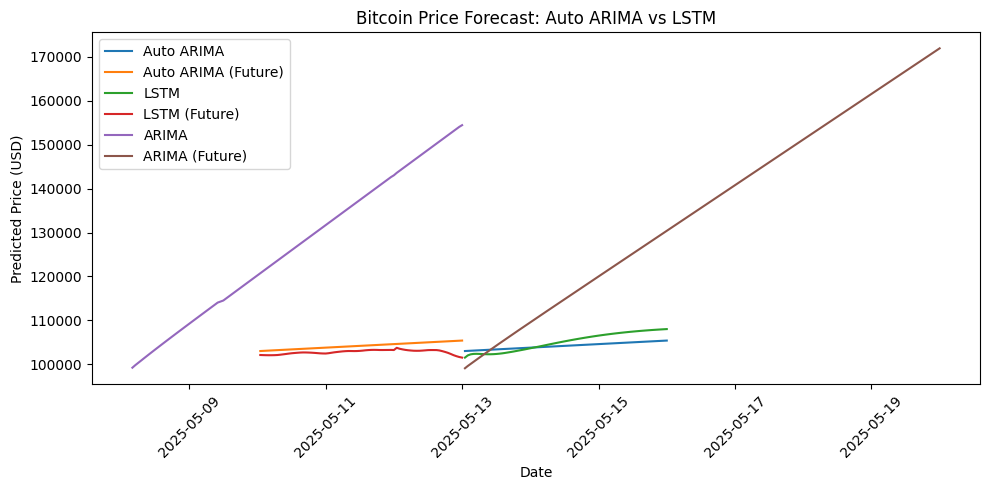

In [49]:
plt.figure(figsize=(10,5))
plt.plot(auto_arima_forecast['date'], auto_arima_forecast['predicted_price'], label='Auto ARIMA')
plt.plot(auto_arima_future['date'], auto_arima_future['predicted_price'], label='Auto ARIMA (Future)')
plt.plot(lstm_forecast['date'], lstm_forecast['predicted_price'], label='LSTM')
plt.plot(lstm_future['date'], lstm_future['predicted_price'], label='LSTM (Future)')
plt.plot(forecast_results['date'], forecast_results['predicted_price'], label='ARIMA')
plt.plot(future_forecast['date'], future_forecast['predicted_price'], label='ARIMA (Future)')
plt.legend()
plt.title('Bitcoin Price Forecast: Auto ARIMA vs LSTM')
plt.xlabel('Date')
plt.ylabel('Predicted Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

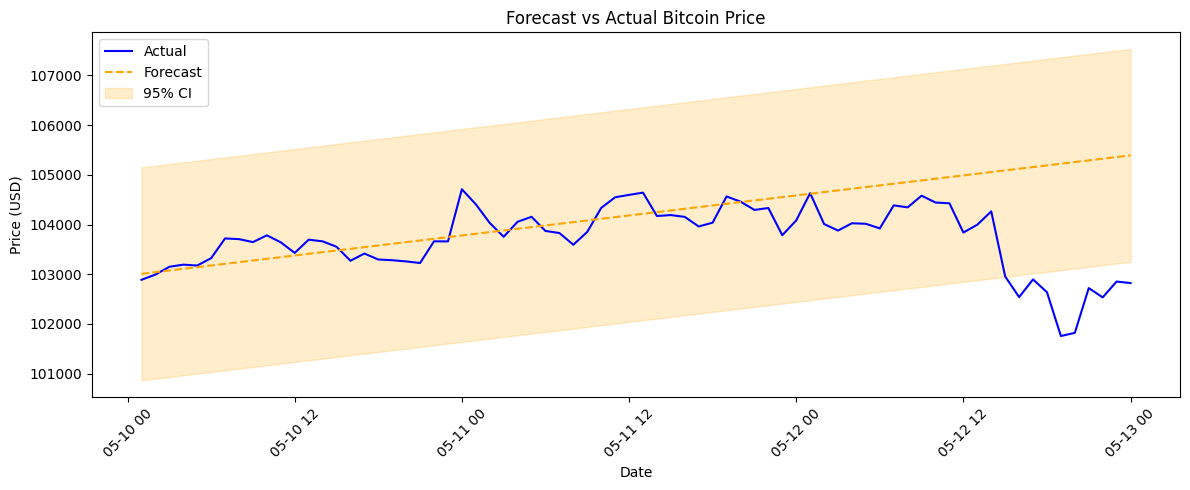

In [50]:
if auto_arima_forecast is not None:
    plot_forecast(auto_arima_future)

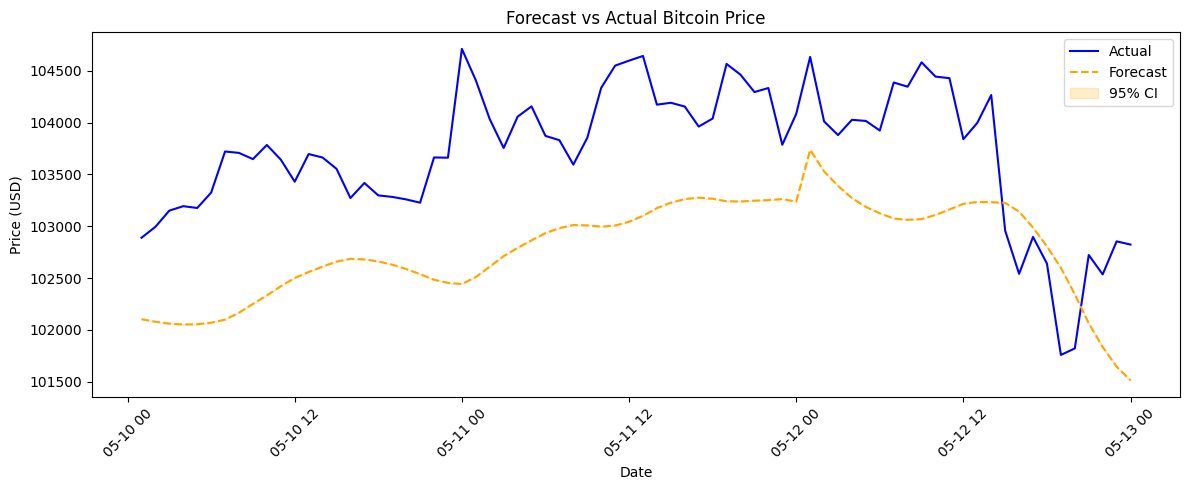

In [51]:
if lstm_future is not None:
    plot_forecast(lstm_future)

In [52]:
display(auto_arima_forecast)

,date,predicted_price
0,2025-05-13 01:00:00,103008.471792
1,2025-05-13 02:00:00,103042.036034
2,2025-05-13 03:00:00,103075.600276
3,2025-05-13 04:00:00,103109.164518
4,2025-05-13 05:00:00,103142.728760
...,...,...
67,2025-05-15 20:00:00,105257.276003
68,2025-05-15 21:00:00,105290.840245
69,2025-05-15 22:00:00,105324.404487
70,2025-05-15 23:00:00,105357.968729


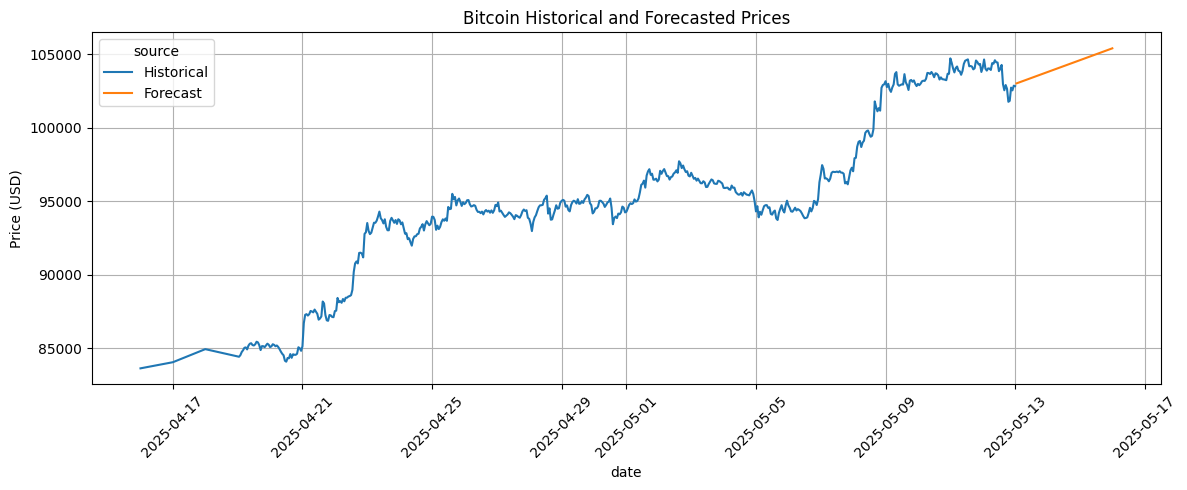

In [53]:
auto_arima_forecast_future = auto_arima_forecast.copy()
auto_arima_forecast_future['price'] = auto_arima_forecast_future['predicted_price']
auto_arima_forecast_future['source'] = 'Forecast'

auto_arima_forecast_historical = merged_data[['date', 'close_price']].copy()
auto_arima_forecast_historical['price'] = auto_arima_forecast_historical['close_price']
auto_arima_forecast_historical['source'] = 'Historical'

trend_df = pd.concat([auto_arima_forecast_historical[['date', 'price', 'source']], auto_arima_forecast_future[['date', 'price', 'source']]])

# plot it
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_df, x='date', y='price', hue='source')
plt.title('Bitcoin Historical and Forecasted Prices')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
display(lstm_forecast)

,date,predicted_price
0,2025-05-13 01:00:00,101513.389002
1,2025-05-13 02:00:00,102013.814883
2,2025-05-13 03:00:00,102252.995906
3,2025-05-13 04:00:00,102352.396187
4,2025-05-13 05:00:00,102373.091236
...,...,...
67,2025-05-15 20:00:00,107847.662625
68,2025-05-15 21:00:00,107890.079942
69,2025-05-15 22:00:00,107930.648768
70,2025-05-15 23:00:00,107969.436917


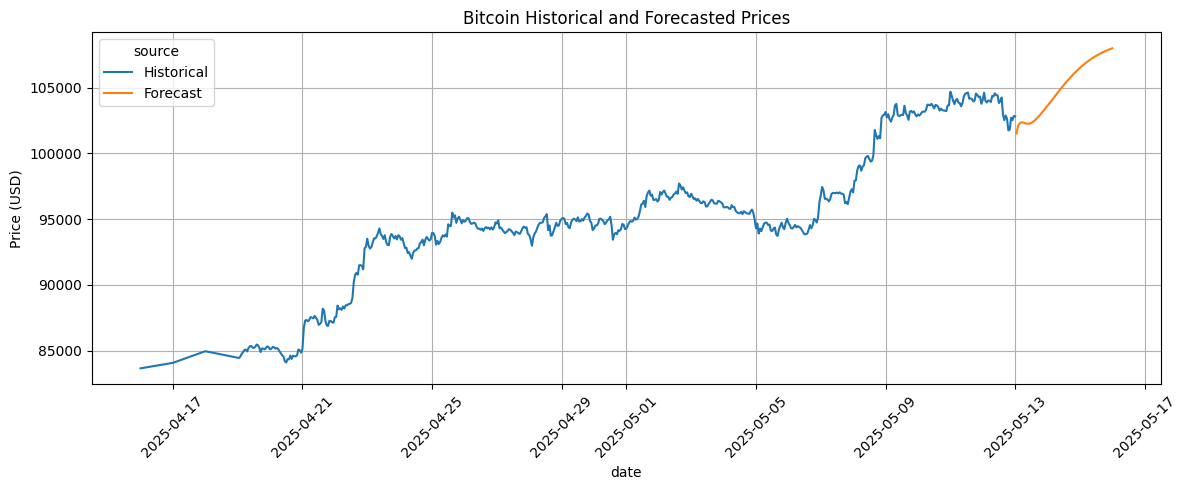

In [55]:
lstm_forecast_future = lstm_forecast.copy()
lstm_forecast_future['price'] = lstm_forecast_future['predicted_price']
lstm_forecast_future['source'] = 'Forecast'

lstm_forecast_historical = merged_data[['date', 'close_price']].copy()
lstm_forecast_historical['price'] = lstm_forecast_historical['close_price']
lstm_forecast_historical['source'] = 'Historical'

trend_df = pd.concat([lstm_forecast_historical[['date', 'price', 'source']], lstm_forecast_future[['date', 'price', 'source']]])

# plot it
plt.figure(figsize=(12, 5))

sns.lineplot(data=trend_df, x='date', y='price', hue='source')
plt.title('Bitcoin Historical and Forecasted Prices')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()